# Gaussian covariance paths for stochastic interpolants

This notebook generates the covariance ellipse figures used in the paper and
checks the closed-form map for independent Gaussian endpoints.  Let
\[
X_0\sim\mathcal N(0,\Sigma_0),\qquad
X_1\sim\mathcal N(0,\Sigma_1)
\]
be independent and \(X_t=a(t)X_0+b(t)X_1\).  Then
\[
\Sigma_t=\operatorname{Cov}(X_t)=a(t)^2\Sigma_0+b(t)^2\Sigma_1.
\]
The conditional expectation velocity is linear,
\[
u_t(x)=B_tx,\qquad
B_t=(a\dot a\,\Sigma_0+b\dot b\,\Sigma_1)\Sigma_t^{-1}.
\]

## Closed-form flow map

Set
\[
A=\Sigma_0^{-1/2}\Sigma_1\Sigma_0^{-1/2},
\qquad
M_t=a(t)^2I+b(t)^2A.
\]
Since \(M_t\) and \(\dot M_t\) commute, the linear flow generated by \(B_t\)
has the explicit solution
\[
T_t=\Sigma_0^{1/2}M_t^{1/2}\Sigma_0^{-1/2}.
\]
At \(t=1\), this map sends \(\Sigma_0\) to \(\Sigma_1\), but it is generally
not symmetric and therefore generally not the Gaussian optimal-transport map.

In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "python":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "python"))

FIG_DIR = PROJECT_ROOT / "paper" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import torch

from stochastic_interpolants import (
    DTYPE,
    SCHEDULES,
    ellipse_points,
    gaussian_covariance,
    gaussian_flow_map,
    gaussian_ot_map,
)

torch.set_default_dtype(DTYPE)
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "legend.frameon": False,
})

In [2]:
theta = np.deg2rad(58.0)
R = torch.tensor(
    [[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]],
    dtype=DTYPE,
)

sigma0 = torch.tensor([[1.75, 0.34], [0.34, 0.55]], dtype=DTYPE)
sigma1 = R @ torch.diag(torch.tensor([0.24, 3.10], dtype=DTYPE)) @ R.T

print("Sigma0 =")
print(sigma0.numpy())
print("Sigma1 =")
print(sigma1.numpy())
print("commutator Frobenius norm:", torch.linalg.norm(sigma0 @ sigma1 - sigma1 @ sigma0).item())

Sigma0 =
[[1.75 0.34]
 [0.34 0.55]]
Sigma1 =
[[ 2.29687074 -1.28527549]
 [-1.28527549  1.04312926]]
commutator Frobenius norm: 2.784024618295545


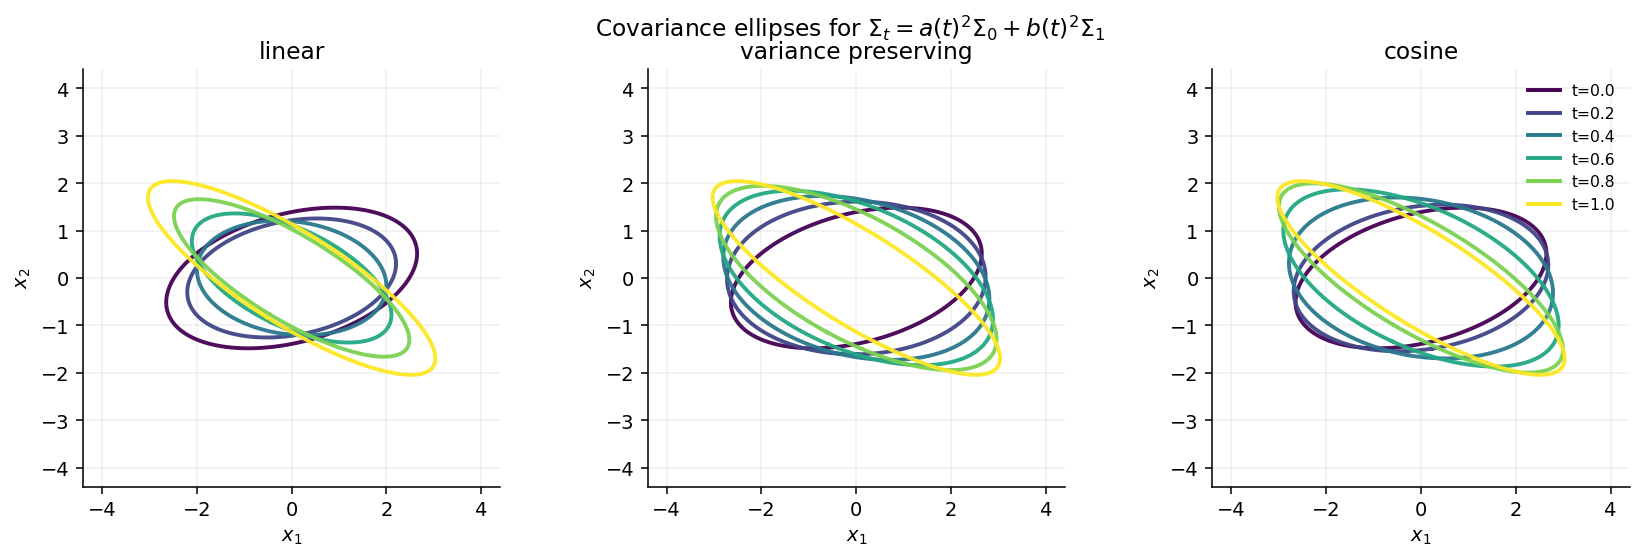

In [3]:
t_values = np.linspace(0.0, 1.0, 6)
fig, axes = plt.subplots(1, 3, figsize=(12.1, 3.7), constrained_layout=True)

for ax, info in zip(axes, SCHEDULES):
    for j, t in enumerate(t_values):
        cov = gaussian_covariance(float(t), sigma0, sigma1, info.key).numpy()
        ell = ellipse_points(cov, level=2.0)
        color = plt.cm.viridis(j / (len(t_values) - 1))
        ax.plot(ell[:, 0], ell[:, 1], color=color, lw=2.0, alpha=0.95)
    ax.set_aspect("equal")
    ax.set_xlim(-4.4, 4.4)
    ax.set_ylim(-4.4, 4.4)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(info.label)

legend_handles = [
    Line2D([0], [0], color=plt.cm.viridis(j / (len(t_values) - 1)), lw=2, label=f"t={t:.1f}")
    for j, t in enumerate(t_values)
]
axes[-1].legend(handles=legend_handles, loc="upper right", fontsize=8)
fig.suptitle(r"Covariance ellipses for $\Sigma_t=a(t)^2\Sigma_0+b(t)^2\Sigma_1$", y=1.04)
fig.savefig(FIG_DIR / "gaussian_covariance_ellipses.pdf", bbox_inches="tight")
plt.show()

In [4]:
T_si = gaussian_flow_map(1.0, sigma0, sigma1, "cosine")
T_ot = gaussian_ot_map(sigma0, sigma1)

print("Stochastic-interpolant endpoint map:")
print(T_si.numpy())
print("\nGaussian OT map:")
print(T_ot.numpy())
print("\n||T_si Sigma0 T_si^T - Sigma1||_F =", torch.linalg.norm(T_si @ sigma0 @ T_si.T - sigma1).item())
print("||T_ot Sigma0 T_ot^T - Sigma1||_F =", torch.linalg.norm(T_ot @ sigma0 @ T_ot.T - sigma1).item())
print("||T_si - T_ot||_F =", torch.linalg.norm(T_si - T_ot).item())
print("symmetry defect ||T_si - T_si^T||_F =", torch.linalg.norm(T_si - T_si.T).item())

Stochastic-interpolant endpoint map:
[[ 1.15035433 -1.3976293 ]
 [-0.48963454  1.4096612 ]]

Gaussian OT map:
[[ 1.22083212 -0.69626375]
 [-0.69626375  1.16483295]]

||T_si Sigma0 T_si^T - Sigma1||_F = 2.560743305106871e-15
||T_ot Sigma0 T_ot^T - Sigma1||_F = 1.616509124176106e-15
||T_si - T_ot||_F = 0.7742849962250937
symmetry defect ||T_si - T_si^T||_F = 1.2840985030835963


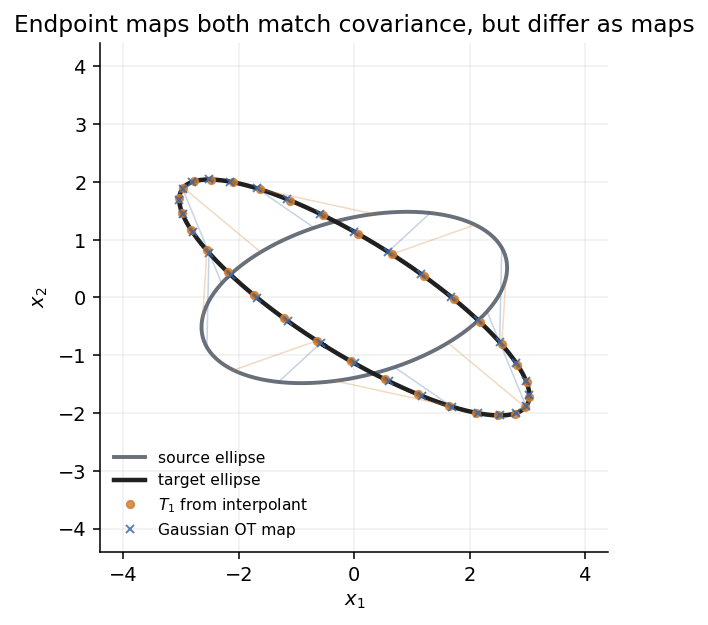

In [5]:
angles = torch.linspace(0.0, 2.0 * torch.pi, 33, dtype=DTYPE)[:-1]
ell0 = ellipse_points(sigma0.numpy(), level=2.0)
ell1 = ellipse_points(sigma1.numpy(), level=2.0)

evals0, evecs0 = torch.linalg.eigh(sigma0)
sigma0_sqrt = (evecs0 * torch.sqrt(evals0)[None, :]) @ evecs0.T
unit = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)
source_curve = 2.0 * (unit @ sigma0_sqrt.T)
si_curve = source_curve @ T_si.T
ot_curve = source_curve @ T_ot.T

fig, ax = plt.subplots(figsize=(5.2, 4.35), constrained_layout=True)
ax.plot(ell0[:, 0], ell0[:, 1], color="#69707a", lw=2, label=r"source ellipse")
ax.plot(ell1[:, 0], ell1[:, 1], color="#202020", lw=2.3, label=r"target ellipse")
ax.plot(si_curve[:, 0], si_curve[:, 1], "o", ms=3.8, color="#d17c2f", alpha=0.82, label=r"$T_1$ from interpolant")
ax.plot(ot_curve[:, 0], ot_curve[:, 1], "x", ms=4.5, color="#3666a6", alpha=0.82, label=r"Gaussian OT map")
for p, q in zip(source_curve[::4].numpy(), si_curve[::4].numpy()):
    ax.plot([p[0], q[0]], [p[1], q[1]], color="#d17c2f", alpha=0.28, lw=0.8)
for p, q in zip(source_curve[2::4].numpy(), ot_curve[2::4].numpy()):
    ax.plot([p[0], q[0]], [p[1], q[1]], color="#3666a6", alpha=0.28, lw=0.8)
ax.set_aspect("equal")
ax.set_xlim(-4.4, 4.4)
ax.set_ylim(-4.4, 4.4)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Endpoint maps both match covariance, but differ as maps")
ax.legend(loc="lower left", fontsize=8)
fig.savefig(FIG_DIR / "gaussian_endpoint_maps.pdf", bbox_inches="tight")
plt.show()